**Classificador de Pneumonia e COVID-19**

*Um segmentador de pneumonia e COVID-19. Por meio dele, será possível identificar se uma imagem de raio-X corresponde a COVID-19 ou pneumonia, auxiliando os médicos na definição de um tratamento específico para o paciente.*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir dataset
!unzip -d ./ drive/MyDrive/images.zip
!unzip -d ./ drive/MyDrive/pneumonia_images.zip
!mv images/ covid_images
!mv covid_images/ pneumonia_images dataset

Streaming output truncated to the last 5000 lines.
  inflating: ./images/COVID-3595.png  
  inflating: ./images/COVID-3596.png  
  inflating: ./images/COVID-3597.png  
  inflating: ./images/COVID-3598.png  
  inflating: ./images/COVID-3599.png  
  inflating: ./images/COVID-36.png   
  inflating: ./images/COVID-360.png  
  inflating: ./images/COVID-3600.png  
  inflating: ./images/COVID-3601.png  
  inflating: ./images/COVID-3602.png  
  inflating: ./images/COVID-3603.png  
  inflating: ./images/COVID-3604.png  
  inflating: ./images/COVID-3605.png  
  inflating: ./images/COVID-3606.png  
  inflating: ./images/COVID-3607.png  
  inflating: ./images/COVID-3608.png  
  inflating: ./images/COVID-3609.png  
  inflating: ./images/COVID-361.png  
  inflating: ./images/COVID-3610.png  
  inflating: ./images/COVID-3611.png  
  inflating: ./images/COVID-3612.png  
  inflating: ./images/COVID-3613.png  
  inflating: ./images/COVID-3614.png  
  inflating: ./images/COVID-3615.png  
  inflating: ./i

In [ ]:
import os
# Caminho das pastas do dataset
path_pn = './dataset/pneumonia_images'
path_cov = './dataset/covid_images'
# Quantidade de dados no dataset
print(f"Quantidade de imagens de pneumonia: {len(os.listdir(path=path_pn))}")
print(f"Quantidade de imagens de covid-19: {len(os.listdir(path=path_cov))}")
print(f"Quantidade total: {len(os.listdir(path=path_pn)) + len(os.listdir(path=path_cov))}")

Quantidade de imagens de pneumonia: 4266
Quantidade de imagens de covid-19: 3616
Quantidade total: 7882


# **Pre-Processamento dos dados**
**Fase de pre-processamento**
*Separação do dataset em treinamento e em testes*
- Apenas 20% dos dados serão para validação
- 80% dos dados serão para treino

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

tf.random.set_seed(42) # Pega as mesmas imagens sempre que eu reutilizar o colab;

path = './dataset'

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2, # 20% dos dados setão para testes
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Rotulando as imagens para classificação
# Dados de teste
df_test = datagen.flow_from_directory(
    path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=True
)
# Dados de treinamento
df_train = datagen.flow_from_directory(
    path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

Found 1576 images belonging to 2 classes.
Found 6305 images belonging to 2 classes.


In [ ]:
# Verificar o número de imagens em treinamento e validação
print(f"Número de imagens de treino: {df_train.samples}")
print(f"Número de imagens de validação: {df_test.samples}")

# Verificar as classes presentes
print("Classes no conjunto de treinamento:", df_train.class_indices)
print("Classes no conjunto de validação:", df_test.class_indices)


Número de imagens de treino: 6305
Número de imagens de validação: 1576
Classes no conjunto de treinamento: {'covid_images': 0, 'pneumonia_images': 1}
Classes no conjunto de validação: {'covid_images': 0, 'pneumonia_images': 1}


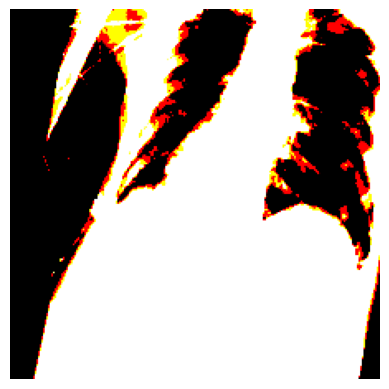

Rótulo da imagem: 0.0


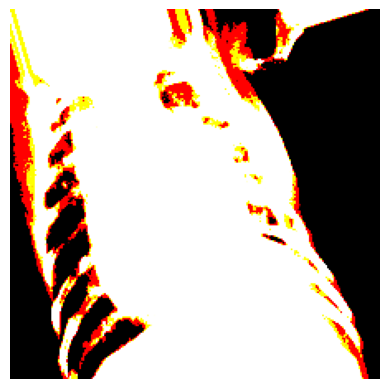

Rótulo da imagem: 1.0


In [ ]:
import matplotlib.pyplot as plt

x_batch, y_batch = next(df_train)

plt.imshow(x_batch[0])
plt.axis('off')
plt.show()
print(f'Rótulo da imagem: {y_batch[0]}')

plt.imshow(x_batch[2])
plt.axis('off')
plt.show()
print(f'Rótulo da imagem: {y_batch[2]}')


# Etapa 1 de Treinamento
**Nessa etapa, será feito o primeiro treinamento do modelo - já pre-treinado - ResNet50**

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Modelo base para o treinamento
modelo_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Congelando as camadas base
modelo_base.trainable = False

# Criação do modelo
modelo = Sequential(
    [
        modelo_base,
        GlobalAveragePooling2D(),
        Dense(1024, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ]
)

In [ ]:
from tensorflow.keras.metrics import Recall, Precision

# Compilar modelo
modelo.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall]
)

In [ ]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,686,913 (97.99 MB)

 Trainable params: 2,099,201 (8.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Treinamento do modelo
trainamento = modelo.fit(
    df_train,
    epochs=10,
    validation_data=df_test,
    validation_steps=df_test.samples // df_test.batch_size
)


Epoch 1/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9428 - loss: 0.1356 - precision_2: 0.9430 - recall: 0.9486

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


198/198 ━━━━━━━━━━━━━━━━━━━━ 1387s 7s/step - accuracy: 0.9429 - loss: 0.1352 - precision_2: 0.9432 - recall: 0.9488 - val_accuracy: 0.9872 - val_loss: 0.0420 - val_precision_2: 0.9952 - val_recall: 0.9812
Epoch 2/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 1379s 7s/step - accuracy: 0.9909 - loss: 0.0299 - precision_2: 0.9932 - recall: 0.9900 - val_accuracy: 0.9930 - val_loss: 0.0251 - val_precision_2: 0.9918 - val_recall: 0.9953
Epoch 3/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 1353s 7s/step - accuracy: 0.9973 - loss: 0.0115 - precision_2: 0.9985 - recall: 0.9966 - val_accuracy: 0.9943 - val_loss: 0.0232 - val_precision_2: 0.9918 - val_recall: 0.9976
Epoch 4/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 1402s 7s/step - accuracy: 0.9968 - loss: 0.0149 - precision_2: 0.9961 - recall: 0.9981 - val_accuracy: 0.9917 - val_loss: 0.0236 - val_precision_2: 0.9883 - val_recall: 0.9965
Epoch 5/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 1365s 7s/step - accuracy: 0.9962 - loss: 0.0116 - precision_2: 0.9964 - recall: 0.9966 - val_accuracy: 0.99

In [ ]:
# Criando pasta para salvar o modelo treinado;
dir_model = "./drive/MyDrive/trained_model"
os.makedirs(dir_model, exist_ok=True)

In [ ]:
# Modelo treinado
modelo.save(f'{dir_model}/modelo.keras') # Error

TypeError: Recall.get_config() missing 1 required positional argument: 'self'

In [ ]:
# Recompilando o Modelo
modelo.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

In [ ]:
# Salvando corretamente
modelo.save(f"{dir_model}/modelo.keras")

In [ ]:
# Salvando os indices das classes
import json

with open(f'{dir_model}/class_indices.json', 'w') as f:
  json.dump(df_train.class_indices, f)

In [ ]:
# Salvando histórico de treinamento
with open(f'{dir_model}/history.json', 'w') as f:
    json.dump(trainamento.history, f)


NameError: name 'json' is not defined

# **Etapa 2**: *Importando o Modelo treinado para testes*

In [ ]:
# Importando o modelo salvo
from tensorflow.keras.models import load_model
modelo = load_model(f'{dir_model}/modelo.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
import numpy as np

# Pegando imagem de teste
x_batch, y_batch = next(df_test)

img = x_batch[10]
img = np.expand_dims(img, axis=0)

print(modelo.input_shape)
print(img.shape)

(None, 224, 224, 3)
(1, 224, 224, 3)


In [ ]:
# Exemplo de previsão de classe
pred = modelo.predict(img)
classe = "PNEUMONIA" if pred[0][0] > 0.5 else "COVID"
real = "PNEUMONIA" if float(y_batch[10]) > 0.5 else "COVID"
print("PREVISÃO:" ,classe)
print("CLASSE REAL:", real)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
PREVISÃO: COVID
CLASSE REAL: COVID


In [ ]:
!mkdir testes_pneumonia_5
!mv *.jpeg testes_pneumonia_5

mv: cannot stat '*.jpeg': No such file or directory


In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input

path = "./testes_pneumonia_5"
TARGET_SIZE = (224, 224)

def load_and_preprocess(img_path, target_size=TARGET_SIZE):
    img = load_img(img_path, target_size=target_size)
    arr = img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)
    return arr

# pegar apenas arquivos de imagem
image_paths = [
    os.path.join(path, fname)
    for fname in os.listdir(path)
    if fname.lower().endswith(('.png', '.jpg', '.jpeg'))
]

batches = [load_and_preprocess(p) for p in image_paths]
X_test = np.vstack(batches)

print("X_test shape:", X_test.shape)


ValueError: need at least one array to concatenate

In [ ]:
# Teste com dados nunca visto
preds = modelo.predict(X_test)


NameError: name 'X_test' is not defined

In [ ]:
def decode_preds(preds, threshold=0.5):
  preds = np.asarray(preds)
  # Validando o shape do preds
  if preds.ndim != 2 or preds.shape[1] != 1:
    raise ValueError(
        f"Formato inesperado de saída do modelo: {preds.shape}"
    )
  probs = preds[:, 0]
  labels = ["PNEUMONIA" if p >= threshold else "COVID" for p in probs]
  return probs, labels

In [ ]:
# probabilidade de resultado e rotulo
probs, labels = decode_preds(preds)
# Lista dos arquivos de imagem teste
image_paths = sorted([
    os.path.join(path, f)
    for f in os.listdir(path)
    if f.lower().endswith((".jpeg", ".jpg", ".png"))
])

NameError: name 'preds' is not defined

In [ ]:
# Impressão dos resultados
for i, img_path in enumerate(image_paths):
  print(
      f"{i+1}. {os.path.basename(img_path)} ->"
      f"Previsto: {labels[i]} (prob {probs[i]:.3f})"
  )

# **ETAPA 3:**
*Fase de testes com uma base de dados encontrada em: https://data.mendeley.com/datasets/2fxz4px6d8/4*

In [ ]:
!wget "https://data.mendeley.com/public-files/datasets/2fxz4px6d8/files/014012df-dadd-4b84-8cb0-3219ea9feec5/file_downloaded"

--2025-12-31 22:40:42--  https://data.mendeley.com/public-files/datasets/2fxz4px6d8/files/014012df-dadd-4b84-8cb0-3219ea9feec5/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.130.86, 162.159.133.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.130.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/bc9f750d-b663-48a7-844e-4e8246751706 [following]
--2025-12-31 22:40:42--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/bc9f750d-b663-48a7-844e-4e8246751706
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 3.5.64.225, 52.218.101.144, 52.218.91.48, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|3.5.64.225|:443..

In [ ]:
!mkdir testes_covid
!unzip file_downloaded -d ./testes_covid

Archive:  file_downloaded
   creating: ./testes_covid/Dataset COVID-19 Augmented/
   creating: ./testes_covid/Dataset COVID-19 Augmented/COVID-19/
  inflating: ./testes_covid/Dataset COVID-19 Augmented/COVID-19/COVID-19 (1).jpeg  
  inflating: ./testes_covid/Dataset COVID-19 Augmented/COVID-19/COVID-19 (1).jpg  
  inflating: ./testes_covid/Dataset COVID-19 Augmented/COVID-19/COVID-19 (1).png  
  inflating: ./testes_covid/Dataset COVID-19 Augmented/COVID-19/COVID-19 (10).jpeg  
  inflating: ./testes_covid/Dataset COVID-19 Augmented/COVID-19/COVID-19 (10).jpg  
  inflating: ./testes_covid/Dataset COVID-19 Augmented/COVID-19/COVID-19 (100).jpg  
  inflating: ./testes_covid/Dataset COVID-19 Augmented/COVID-19/COVID-19 (101).jpg  
  inflating: ./testes_covid/Dataset COVID-19 Augmented/COVID-19/COVID-19 (102).jpg  
  inflating: ./testes_covid/Dataset COVID-19 Augmented/COVID-19/COVID-19 (103).jpg  
  inflating: ./testes_covid/Dataset COVID-19 Augmented/COVID-19/COVID-19 (104).jpg  
  inflati

In [ ]:
# Apagando os Non-COVID-19 e modificando o nome do diretório
!mv ./testes_covid/Dataset\ COVID-19\ Augmented ./testes_covid/data_test
!rm -rf ./testes_covid/data_test/Non-COVID-19

In [ ]:
!unzip drive/MyDrive/pneumonia.zip -d ./
!mv PNEUMONIA/ pneumonia_testes

Archive:  drive/MyDrive/pneumonia.zip
   creating: ./PNEUMONIA/
  inflating: ./PNEUMONIA/person33_virus_72.jpeg  
  inflating: ./PNEUMONIA/person1029_virus_1721.jpeg  
  inflating: ./PNEUMONIA/person616_virus_1186.jpeg  
  inflating: ./PNEUMONIA/person646_virus_1227.jpeg  
  inflating: ./PNEUMONIA/person110_virus_206.jpeg  
  inflating: ./PNEUMONIA/person88_virus_161.jpeg  
  inflating: ./PNEUMONIA/person734_virus_1355.jpeg  
  inflating: ./PNEUMONIA/person1298_virus_2226.jpeg  
  inflating: ./PNEUMONIA/person514_virus_1031.jpeg  
  inflating: ./PNEUMONIA/person1180_virus_2008.jpeg  
  inflating: ./PNEUMONIA/person434_virus_884.jpeg  
  inflating: ./PNEUMONIA/person658_virus_1241.jpeg  
  inflating: ./PNEUMONIA/person1678_virus_2895.jpeg  
  inflating: ./PNEUMONIA/person332_virus_685.jpeg  
  inflating: ./PNEUMONIA/person1083_virus_1795.jpeg  
  inflating: ./PNEUMONIA/person1145_virus_1905.jpeg  
  inflating: ./PNEUMONIA/person326_virus_666.jpeg  
  inflating: ./PNEUMONIA/person124_vir

In [ ]:
import random

# Testando Quantos acertos o modelo faz de COVID-19 e PNEUMONIA
caminho_covid = "./testes_covid/data_test/COVID-19"
caminho_pneumonia = "./pneumonia_testes/"
TARGET_SIZE = (224, 224)
# caminhos das imagens de covid
imagens_covid_path = [
    os.path.join(caminho_covid, fname)
    for fname in os.listdir(caminho_covid)
    if fname.lower().endswith(('.png', '.jpg', '.jpeg'))
]
# caminhos das imagens de pneumonia
imagens_pneumonia_path = [
    os.path.join(caminho_pneumonia, fname)
    for fname in os.listdir(caminho_pneumonia)
    if fname.lower().endswith(('.png', '.jpg', '.jpeg'))
]

# Caminhos das duas doenças
n = 25
image_caminhos = (
    random.sample(imagens_covid_path, n) +
    random.sample(imagens_pneumonia_path, n)
)

batches = [load_and_preprocess(p) for p in image_caminhos]
X_test = np.vstack(batches)

# Shape do X_test Atual
print("X_test shape:", X_test.shape)
print(len(image_caminhos))

X_test shape: (50, 224, 224, 3)
50


In [ ]:
# Quantidade de imagens
assert len(X_test) == len(image_caminhos)

In [ ]:
# Previsão
_predict_ = modelo.predict(X_test)
probs, labels = decode_preds(_predict_)


2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step


In [ ]:
y_test = np.array([
    0 if "COVID" in p.upper() else 1
    for p in image_caminhos
])
probs = _predict_.ravel()              # (N,1) → (N,)
y_pred = (probs >= 0.5).astype(int)    # threshold


In [ ]:
for i, path in enumerate(image_caminhos):
    real = "COVID" if y_test[i] == 0 else "PNEUMONIA"
    pred = "COVID" if y_pred[i] == 0 else "PNEUMONIA"
    status = "✅ ACERTO" if y_pred[i] == y_test[i] else "❌ ERRO"

    print(f"{status} | Real: {real} | Pred: {pred} | Prob: {probs[i]:.4f}")
    print(f"Imagem: {path}\n")


✅ ACERTO | Real: COVID | Pred: COVID | Prob: 0.0337
Imagem: ./testes_covid/data_test/COVID-19/COVID-19 (554).jpg

❌ ERRO | Real: COVID | Pred: PNEUMONIA | Prob: 0.8803
Imagem: ./testes_covid/data_test/COVID-19/COVID-19 (30).jpg

✅ ACERTO | Real: COVID | Pred: COVID | Prob: 0.0719
Imagem: ./testes_covid/data_test/COVID-19/COVID-19 (706).jpg

✅ ACERTO | Real: COVID | Pred: COVID | Prob: 0.3023
Imagem: ./testes_covid/data_test/COVID-19/COVID-19 (423).jpg

✅ ACERTO | Real: COVID | Pred: COVID | Prob: 0.0115
Imagem: ./testes_covid/data_test/COVID-19/COVID-19 (599).jpg

✅ ACERTO | Real: COVID | Pred: COVID | Prob: 0.1735
Imagem: ./testes_covid/data_test/COVID-19/COVID-19 (323).jpg

✅ ACERTO | Real: COVID | Pred: COVID | Prob: 0.1140
Imagem: ./testes_covid/data_test/COVID-19/COVID-19 (448).jpg

✅ ACERTO | Real: COVID | Pred: COVID | Prob: 0.3182
Imagem: ./testes_covid/data_test/COVID-19/COVID-19 (876).jpg

✅ ACERTO | Real: COVID | Pred: COVID | Prob: 0.1958
Imagem: ./testes_covid/data_test/CO

In [ ]:
acertos = (y_pred == y_test)
print(f"Acertos: {acertos.sum()} / {len(y_test)}")
print(f"Acurácia: {acertos.mean():.4f}")

Acertos: 48 / 50
Acurácia: 0.9600


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(
    y_test, y_pred,
    target_names=["PNEUMONIA", "COVID"]
))


[[23  2]
 [ 0 25]]
              precision    recall  f1-score   support

   PNEUMONIA       1.00      0.92      0.96        25
       COVID       0.93      1.00      0.96        25

    accuracy                           0.96        50
   macro avg       0.96      0.96      0.96        50
weighted avg       0.96      0.96      0.96        50



# **Etapa de Refinamento do Modelo**

In [ ]:
# Ativando as camadas base do modelo ResNet50
modelo_base.trainable = True

for layer in modelo_base.layers[:-30]:
    layer.trainable = False

for layer in modelo_base.layers[-30:]:
    layer.trainable = True

In [ ]:
# O Adam é bom para treinamentos iniciais, o SGD é melhor para refinamento
from tensorflow.keras.optimizers import SGD

modelo.compile(
    optimizer=SGD(learning_rate=1e-4, momentum=0.9),
    loss="binary_crossentropy",
    metrics=["accuracy", "AUC"]
)


In [ ]:
modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,686,913 (97.99 MB)

 Trainable params: 2,099,201 (8.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
base_model = modelo.layers[0]

base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

for layer in base_model.layers[-40:]:
    layer.trainable = True


In [ ]:
# recompilando o modelo
modelo.compile(
    optimizer=SGD(
        learning_rate=1e-4,
        momentum=0.9,
        nesterov=True
    ),
    loss="binary_crossentropy",
    metrics=["accuracy", "AUC"]
)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

callbacks = [early_stop, reduce_lr]

history_finetune = modelo.fit(
    df_train,
    validation_data=df_test,
    epochs=10,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 2490s 13s/step - AUC: 0.9993 - accuracy: 0.9687 - loss: 0.0832 - val_AUC: 0.9999 - val_accuracy: 0.9956 - val_loss: 0.0135 - learning_rate: 1.0000e-04
Epoch 2/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 2414s 12s/step - AUC: 0.9999 - accuracy: 0.9950 - loss: 0.0156 - val_AUC: 0.9999 - val_accuracy: 0.9949 - val_loss: 0.0142 - learning_rate: 1.0000e-04
Epoch 3/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 2402s 12s/step - AUC: 0.9999 - accuracy: 0.9941 - loss: 0.0173 - val_AUC: 0.9999 - val_accuracy: 0.9943 - val_loss: 0.0125 - learning_rate: 1.0000e-04
Epoch 4/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 2407s 12s/step - AUC: 0.9998 - accuracy: 0.9951 - loss: 0.0122 - val_AUC: 0.9991 - val_accuracy: 0.9956 - val_loss: 0.0171 - learning_rate: 1.0000e-04
Epoch 5/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 2395s 12s/step - AUC: 0.9999 - accuracy: 0.9936 - loss: 0.0153 - val_AUC: 0.9999 - val_accuracy: 0.9962 - val_loss: 0.0133 - learning_rate: 1.0000e-04
Epoch 6/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 2411s

In [ ]:
!mkdir ./drive/MyDrive/finetuned

In [ ]:
dir_model_finetuned = "./drive/MyDrive/finetuned"

# Salvando o modelo refinado
modelo.save(f"{dir_model_finetuned}/resnet50_finetuned_covid_pneumonia.keras")


**Novos testes com o modelo Refinado**


In [ ]:
# Previsão
predict_ref = modelo.predict(X_test)
probs, labels = decode_preds(predict_ref)


2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step


In [ ]:
y_test_rf = np.array([
    0 if "COVID" in p.upper() else 1
    for p in image_caminhos
])
probs_rf = predict_ref.ravel()              # (N,1) → (N,)
y_pred_rf = (probs_rf >= 0.6).astype(int)    # threshold


In [ ]:
for i, path in enumerate(image_caminhos):
    real = "COVID" if y_test_rf[i] == 0 else "PNEUMONIA"
    pred = "COVID" if y_pred_rf[i] == 0 else "PNEUMONIA"
    status = "✅ ACERTO" if y_pred_rf[i] == y_test_rf[i] else "❌ ERRO"

    print(f"{status} | Real: {real} | Pred: {pred} | Prob: {probs_rf[i]:.4f}")
    print(f"Imagem: {path}\n")


✅ ACERTO | Real: COVID | Pred: COVID | Prob: 0.0337
Imagem: ./testes_covid/data_test/COVID-19/COVID-19 (554).jpg

❌ ERRO | Real: COVID | Pred: PNEUMONIA | Prob: 0.8803
Imagem: ./testes_covid/data_test/COVID-19/COVID-19 (30).jpg

✅ ACERTO | Real: COVID | Pred: COVID | Prob: 0.0719
Imagem: ./testes_covid/data_test/COVID-19/COVID-19 (706).jpg

✅ ACERTO | Real: COVID | Pred: COVID | Prob: 0.3023
Imagem: ./testes_covid/data_test/COVID-19/COVID-19 (423).jpg

✅ ACERTO | Real: COVID | Pred: COVID | Prob: 0.0115
Imagem: ./testes_covid/data_test/COVID-19/COVID-19 (599).jpg

✅ ACERTO | Real: COVID | Pred: COVID | Prob: 0.1735
Imagem: ./testes_covid/data_test/COVID-19/COVID-19 (323).jpg

✅ ACERTO | Real: COVID | Pred: COVID | Prob: 0.1140
Imagem: ./testes_covid/data_test/COVID-19/COVID-19 (448).jpg

✅ ACERTO | Real: COVID | Pred: COVID | Prob: 0.3182
Imagem: ./testes_covid/data_test/COVID-19/COVID-19 (876).jpg

✅ ACERTO | Real: COVID | Pred: COVID | Prob: 0.1958
Imagem: ./testes_covid/data_test/CO

In [ ]:
acertos = (y_pred == y_test)
print(f"Acertos: {acertos.sum()} / {len(y_test)}")
print(f"Acurácia: {acertos.mean():.4f}")

Acertos: 48 / 50
Acurácia: 0.9600


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(
    y_test, y_pred,
    target_names=["PNEUMONIA", "COVID"]
))


[[23  2]
 [ 0 25]]
              precision    recall  f1-score   support

   PNEUMONIA       1.00      0.92      0.96        25
       COVID       0.93      1.00      0.96        25

    accuracy                           0.96        50
   macro avg       0.96      0.96      0.96        50
weighted avg       0.96      0.96      0.96        50

